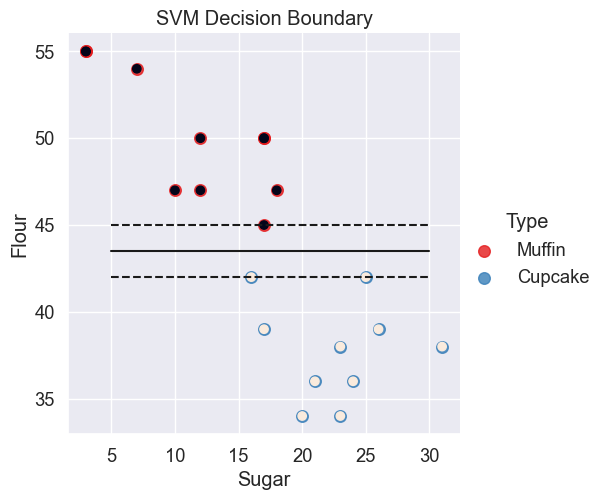

Confusion Matrix:
 [[2 0]
 [1 1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [3]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn import svm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.2)

# Load dataset
recipes = pd.read_csv("C:\\Users\\karth\\Downloads\\muffins.csv")

# Visualize dataset
sns.lmplot(x='Sugar', y='Flour', data=recipes, hue='Type',
           palette='Set1', fit_reg=False, scatter_kws={"s": 70})

# Prepare data
X = recipes[['Sugar', 'Flour']].values
y = np.where(recipes['Type'] == 'Muffin', 0, 1)

# Train SVM model
model = svm.SVC(kernel='linear')
model.fit(X, y)

# Decision boundary
w = model.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(5, 30)
yy = a * xx - (model.intercept_[0] / w[1])

# Support vectors
b = model.support_vectors_[0]
yy_down = a * xx + (b[1] - a * b[0])

b = model.support_vectors_[-1]
yy_up = a * xx + (b[1] - a * b[0])

# Plot boundary
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.plot(xx, yy, 'k-')
plt.plot(xx, yy_down, 'k--')
plt.plot(xx, yy_up, 'k--')
plt.scatter(model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=80, facecolors='none')
plt.xlabel("Sugar")
plt.ylabel("Flour")
plt.title("SVM Decision Boundary")
plt.show()

# Train-test split
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train new model
model1 = svm.SVC(kernel='linear')
model1.fit(X_train, y_train)

# Prediction
pred = model1.predict(X_test)

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))